In [ ]:
import pandas as pd
from utils import preprocess
from utils import models

#-------------------------------------- EDA TO STUDY THE DATASET --------------------------------------#

df_customers, df_articles, df_transactions = preprocess.load_dataset()


In [5]:
df_articles['prod_name'].nunique()

45875

In [3]:
#-------------------------------------- CUSTOMERS DATA STUDY --------------------------------------#

df_customers.info()

df_customers.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  str    
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  str    
 4   fashion_news_frequency  1355969 non-null  str    
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  str    
dtypes: float64(3), str(4)
memory usage: 256.7 MB


,FN,Active,age
count,476930.0,464404.0,1.356119e+06
mean,1.0,1.0,3.638696e+01
std,0.0,0.0,1.431363e+01
min,1.0,1.0,1.600000e+01
25%,1.0,1.0,2.400000e+01
50%,1.0,1.0,3.200000e+01
75%,1.0,1.0,4.900000e+01
max,1.0,1.0,9.900000e+01


In [4]:
#-------------------------------------- ARTICLES DATA STUDY --------------------------------------#

df_articles.info()

df_articles.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   article_id                    105542 non-null  int64
 1   product_code                  105542 non-null  int64
 2   prod_name                     105542 non-null  str  
 3   product_type_no               105542 non-null  int64
 4   product_type_name             105542 non-null  str  
 5   product_group_name            105542 non-null  str  
 6   graphical_appearance_no       105542 non-null  int64
 7   graphical_appearance_name     105542 non-null  str  
 8   colour_group_code             105542 non-null  int64
 9   colour_group_name             105542 non-null  str  
 10  perceived_colour_value_id     105542 non-null  int64
 11  perceived_colour_value_name   105542 non-null  str  
 12  perceived_colour_master_id    105542 non-null  int64
 13  perceived_colour_master_n

,article_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no
count,1.055420e+05,105542.000000,105542.000000,1.055420e+05,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000
mean,6.984246e+08,698424.563378,234.861875,1.009515e+06,32.233822,3.206183,7.807972,4532.777833,3.171534,42.664219,1010.438290
std,1.284624e+08,128462.384432,75.049308,2.241359e+04,28.086154,1.563839,5.376727,2712.692011,4.353234,23.260105,6.731023
min,1.087750e+08,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000
25%,6.169925e+08,616992.500000,252.000000,1.010008e+06,9.000000,2.000000,4.000000,1676.000000,1.000000,20.000000,1005.000000
50%,7.022130e+08,702213.000000,259.000000,1.010016e+06,14.000000,4.000000,5.000000,4222.000000,2.000000,46.000000,1009.000000
75%,7.967030e+08,796703.000000,272.000000,1.010016e+06,52.000000,4.000000,11.000000,7389.000000,4.000000,61.000000,1017.000000
max,9.594610e+08,959461.000000,762.000000,1.010029e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000


In [5]:
#-------------------------------------- TRANSACTIONS DATA STUDY --------------------------------------#

df_transactions.info()

df_transactions.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             str    
 1   customer_id       str    
 2   article_id        int64  
 3   price             float64
 4   sales_channel_id  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.4 GB


,article_id,price,sales_channel_id
count,3.178832e+07,3.178832e+07,3.178832e+07
mean,6.962272e+08,2.782927e-02,1.704028e+00
std,1.334480e+08,1.918113e-02,4.564786e-01
min,1.087750e+08,1.694915e-05,1.000000e+00
25%,6.328030e+08,1.581356e-02,1.000000e+00
50%,7.145820e+08,2.540678e-02,2.000000e+00
75%,7.865240e+08,3.388136e-02,2.000000e+00
max,9.562170e+08,5.915254e-01,2.000000e+00


In [3]:
df_customers_filtered, df_products, df_transactions_filtered = preprocess.load_complete_dataset_filtered_number_customers(500)
df_transactions_filtered = preprocess.filter_customers_by_activity(df_transactions_filtered, min_purchases=3, max_months_since_last_purchase=12)
#df_transactions_filtered = preprocess.transactions_group(df_transactions_filtered)
print(len(df_transactions))
print(len(df_transactions_filtered))
#df_complete = preprocess.merge_datasets_inner(df_customers_filtered, df_products, df_transactions_filtered)



31788324
47276


In [4]:
# 1. Cargamos tu muestra filtrada de 500 clientes
df_customers_filtered, df_products, df_transactions_filtered = (
    preprocess.load_complete_dataset_filtered_number_customers(100)
)

print("⚡ Generando features bases de usuario y artículo...")
# Usamos las funciones de tu pipeline para extraer las métricas de negocio
article_df = models.compute_article_features(
    df_customers_filtered, df_products, df_transactions_filtered
)
user_df = models.compute_user_features(
    df_customers_filtered, df_transactions_filtered, df_products
)

# 2. Creamos la base del dataset (Pares cliente-artículo reales)
positivos = (
    df_transactions_filtered[["customer_id", "article_id"]]
    .drop_duplicates()
    .copy()
)
positivos["label"] = 1

# 3. Hacemos los Joins planos (manteniendo los textos originales sin get_dummies)
print("🔗 Realizando uniones de datos...")
dataset = positivos.merge(user_df, on="customer_id", how="left").merge(
    article_df, on="article_id", how="left"
)

# 4. ¡AQUÍ ENTRAN TUS CROSS FEATURES!
print("🧠 Calculando cross_features...")
dataset = models.compute_cross_features(dataset)

# 5. Imputamos nulos
print("🧼 Imputando valores nulos...")
dataset = preprocess.imputar_nulos_tfm(dataset)

# 6. Ejecutamos vuestra función de optimización automática
print("🧬 Optimizando categorías (filtro ratio < 0.05)...")
dataset = preprocess.auto_optimize_categories(
    dataset,
    max_ratio=0.05,
    max_categories=500,
    exclude_cols=["customer_id", "article_id"],
)

# 7. Nos quedamos solo con la matriz X final que iría al modelo
cols_no_feature = ["customer_id", "article_id", "label", "sample_weight"]
feature_cols = [c for c in dataset.columns if c not in cols_no_feature]
X_test_audit = dataset[feature_cols].copy()

# ============================================================
# 📊 CELDA DE CONTROL: COMPROBACIÓN DE TIPOS PARA XGBOOST
# ============================================================
columnas_objeto = (
    X_test_audit.select_dtypes(include=["object", "string"]).columns.tolist()
)

print("\n" + "=" * 60)
print("🔍 AUDITORÍA DE TIPOS DE DATOS PARA XGBOOST")
print("=" * 60)

if len(columnas_objeto) > 0:
    print(
        f"❌ ¡PELIGRO! Se han encontrado {len(columnas_objeto)} columnas tipo 'object' o 'string'."
    )
    print(
        f"🚨 Si pasas esta matriz a XGBoost, EL MODELO VA A PETAR con un ValueError."
    )
    print(f"👉 Columnas rebeldes: {columnas_objeto}")
    print("\n💡 Muestra de los textos conflictivos:")
    display(X_test_audit[columnas_objeto].head(3))
else:
    print(
        "✅ ¡TODO LIMPIO! No queda ninguna columna 'object' suelta."
    )
    print(
        "🚀 XGBoost procesará esta matriz de forma nativa a la velocidad del rayo."
    )

print("-" * 60)
print("📊 Resumen final de tipos de variables listas para el modelo:")
print(X_test_audit.dtypes.value_counts())
print("=" * 60)

⚡ Generando features bases de usuario y artículo...
🔗 Realizando uniones de datos...
🧠 Calculando cross_features...
🧼 Imputando valores nulos...
🧬 Optimizando categorías (filtro ratio < 0.05)...

🔍 AUDITORÍA DE TIPOS DE DATOS PARA XGBOOST
❌ ¡PELIGRO! Se han encontrado 2 columnas tipo 'object' o 'string'.
🚨 Si pasas esta matriz a XGBoost, EL MODELO VA A PETAR con un ValueError.
👉 Columnas rebeldes: ['prod_name', 'detail_desc']

💡 Muestra de los textos conflictivos:


,prod_name,detail_desc
0,Kimber dress,Short-sleeved dress in a crêpe weave with a ru...
1,Space jegging,Skinny-fit treggings in superstretch twill wit...
2,Kanta slacks,Ankle-length cigarette trousers in a stretch w...


------------------------------------------------------------
📊 Resumen final de tipos de variables listas para el modelo:
float64     16
int64       12
category     2
str          2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
int8         1
Name: count, dtype: int64


In [4]:
df_transactions_filtered2 = preprocess.filter_customers_by_activity(
    df_transactions,
    min_purchases=3,
    max_months_since_last_purchase=12,
)

In [5]:
len(df_transactions_filtered2)

29248772

In [7]:
df_complete.info()
df_complete.describe()

df_complete.head()

<class 'pandas.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   t_dat                         4011 non-null   str    
 1   customer_id                   4011 non-null   str    
 2   article_id                    4011 non-null   int64  
 3   price                         4011 non-null   float64
 4   sales_channel_id              4011 non-null   int64  
 5   transaction_id                4011 non-null   str    
 6   FN                            1272 non-null   float64
 7   Active                        1272 non-null   float64
 8   club_member_status            4008 non-null   str    
 9   fashion_news_frequency        4004 non-null   str    
 10  age                           3986 non-null   float64
 11  postal_code                   4011 non-null   str    
 12  product_code                  4011 non-null   int64  
 13  prod_name     

,t_dat,customer_id,article_id,price,sales_channel_id,transaction_id,FN,Active,club_member_status,fashion_news_frequency,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,2018-09-21,071f285b750ac606d6c8b1d8bfa7e483759fa698c5795e...,609727005,0.025407,1,0_071f285b750ac606d6c8b1d8bfa7e483759fa698c579...,1.0,1.0,ACTIVE,Regularly,...,Swimwear,B,Lingeries/Tights,1,Ladieswear,60,"Womens Swimwear, beachwear",1018,Swimwear,Fully lined halterneck swimsuit with triangle ...
1,2018-09-21,071f285b750ac606d6c8b1d8bfa7e483759fa698c5795e...,251510001,0.016932,1,0_071f285b750ac606d6c8b1d8bfa7e483759fa698c579...,1.0,1.0,ACTIVE,Regularly,...,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,Push-up tights that lift and shape with an ela...
2,2018-09-21,1ff7bfa91f0b12f134c9192a0b22742e75edf5dd64f590...,564754001,0.020322,2,1_1ff7bfa91f0b12f134c9192a0b22742e75edf5dd64f5...,1.0,1.0,ACTIVE,Regularly,...,Blouse,A,Ladieswear,1,Ladieswear,6,Womens Casual,1010,Blouses,Shirt in a stretch cotton weave with a classic...
3,2018-09-21,1ff7bfa91f0b12f134c9192a0b22742e75edf5dd64f590...,592172007,0.006763,2,1_1ff7bfa91f0b12f134c9192a0b22742e75edf5dd64f5...,1.0,1.0,ACTIVE,Regularly,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Top in lightweight sweatshirt fabric with drop...
4,2018-09-21,ae7c42d870a1e95c745eea786a5d79c401daf3fde83883...,578846001,0.016932,2,2_ae7c42d870a1e95c745eea786a5d79c401daf3fde838...,1.0,1.0,ACTIVE,Regularly,...,Trousers,D,Divided,2,Divided,53,Divided Collection,1009,Trousers,"5-pocket, low-rise jeans in washed stretch den..."


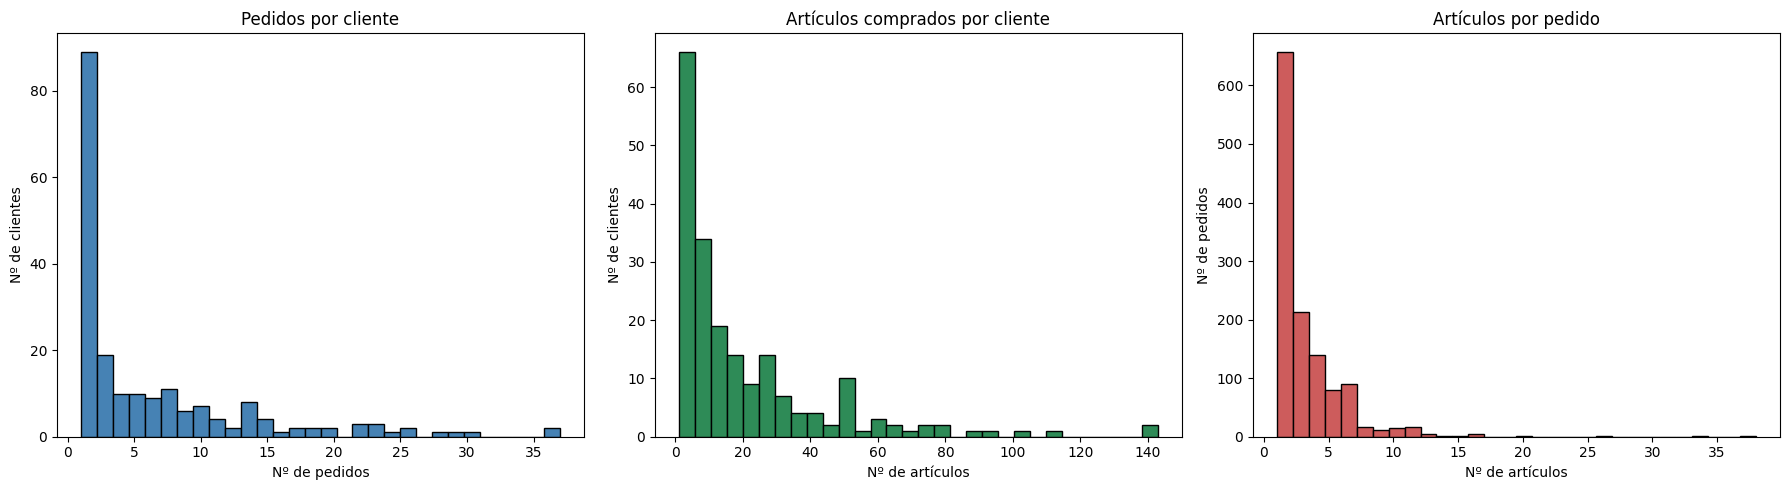

In [8]:
import matplotlib.pyplot as plt

pedidos_por_cliente = df_complete.groupby('customer_id')['transaction_id'].nunique()

articulos_por_cliente = df_complete.groupby('customer_id')['article_id'].count()

articulos_por_pedido = df_complete.groupby('transaction_id')['article_id'].count()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(pedidos_por_cliente, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Pedidos por cliente')
axes[0].set_xlabel('Nº de pedidos')
axes[0].set_ylabel('Nº de clientes')

axes[1].hist(articulos_por_cliente, bins=30, color='seagreen', edgecolor='black')
axes[1].set_title('Artículos comprados por cliente')
axes[1].set_xlabel('Nº de artículos')
axes[1].set_ylabel('Nº de clientes')

axes[2].hist(articulos_por_pedido, bins=30, color='indianred', edgecolor='black')
axes[2].set_title('Artículos por pedido')
axes[2].set_xlabel('Nº de artículos')
axes[2].set_ylabel('Nº de pedidos')

plt.tight_layout()
plt.show()

Tenemos más clintes que han comprado una o dos veces, el dataset está un poco desbalanceado, pero si que en este caso tenemos muchas transacciones por lo que podríamos incluso filtrar por los clientes que hayan hecho al menos 2 o 3 pedidos, para mejorar las recomendaciones. 

In [9]:
#Quiero saber cuantos valores distintos tiene cada columna de mi DataFrame
#df_customers, df_articles, df_transactions
print("--- Valores Únicos y Tipos por Columna ---")
total_filas = len(df_customers) # Cambia 'df' por el nombre de tu DataFrame (ej. df_articles)

for col in df_customers.columns:
    valores_unicos = df_customers[col].nunique()
    tipo_dato = df_customers[col].dtype
    porcentaje = (valores_unicos / total_filas) * 100
    
    print(f"Columna: {col:<30} | Únicos: {valores_unicos:<8} | Tipo: {tipo_dato:<10} | % del total: {porcentaje:.2f}%")

--- Valores Únicos y Tipos por Columna ---


TypeError: unsupported format string passed to StringDtype.__format__

In [ ]:
print("--- Valores Únicos y Tipos por Columna ---")
total_filas = len(df_articles) # Cambia 'df' por el nombre de tu DataFrame (ej. df_articles)

for col in df_articles.columns:
    valores_unicos = df_articles[col].nunique()
    tipo_dato = df_articles[col].dtype
    porcentaje = (valores_unicos / total_filas) * 100
    
    print(f"Columna: {col:<30} | Únicos: {valores_unicos:<8} | Tipo: {tipo_dato:<10} | % del total: {porcentaje:.2f}%")

In [ ]:
print("--- Valores Únicos y Tipos por Columna ---")
total_filas = len(df_transactions) # Cambia 'df' por el nombre de tu DataFrame (ej. df_articles)

for col in df_transactions.columns:
    valores_unicos = df_transactions[col].nunique()
    tipo_dato = df_transactions[col].dtype
    porcentaje = (valores_unicos / total_filas) * 100
    
    print(f"Columna: {col:<30} | Únicos: {valores_unicos:<8} | Tipo: {tipo_dato:<10} | % del total: {porcentaje:.2f}%")

In [12]:
# El atajo rápido de una sola línea
print(len(df_transactions), len(df_customers), len(df_products))
print("\n")
print(df_customers.nunique())
print("\n")
print(df_products.nunique())
print("\n")
print(df_transactions.nunique())

31788324 1371980 105542


customer_id               1371980
FN                              1
Active                          1
club_member_status              3
fashion_news_frequency          3
age                            84
postal_code                352899
dtype: int64


article_id                      105542
product_code                     47224
prod_name                        45875
product_type_no                    132
product_type_name                  131
product_group_name                  19
graphical_appearance_no             30
graphical_appearance_name           30
colour_group_code                   50
colour_group_name                   50
perceived_colour_value_id            8
perceived_colour_value_name          8
perceived_colour_master_id          20
perceived_colour_master_name        20
department_no                      299
department_name                    250
index_code                          10
index_name                          10
index_group_no     

In [16]:
df_articles[['index_code','index_name']].info()
df_articles[['index_code','index_name']].head()

<class 'pandas.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   index_code  105542 non-null  str  
 1   index_name  105542 non-null  str  
dtypes: str(2)
memory usage: 3.1 MB


,index_code,index_name
0,A,Ladieswear
1,A,Ladieswear
2,A,Ladieswear
3,B,Lingeries/Tights
4,B,Lingeries/Tights
